In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("100companyratings.csv")

Text(0.5, 1.0, 'Employee Size Distribution')

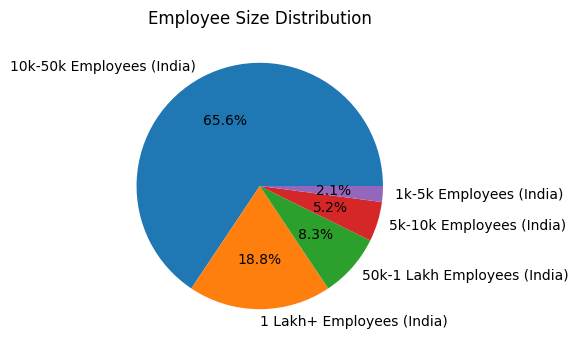

In [32]:
# Pie Chart - Employees abd companies name

plt.figure(figsize=(6, 4))
emp_counts = df['employees'].value_counts()
plt.pie(emp_counts, labels=emp_counts.index, autopct='%1.1f%%')
plt.title("Employee Size Distribution")

Text(0.5, 0, 'Number of Companies')

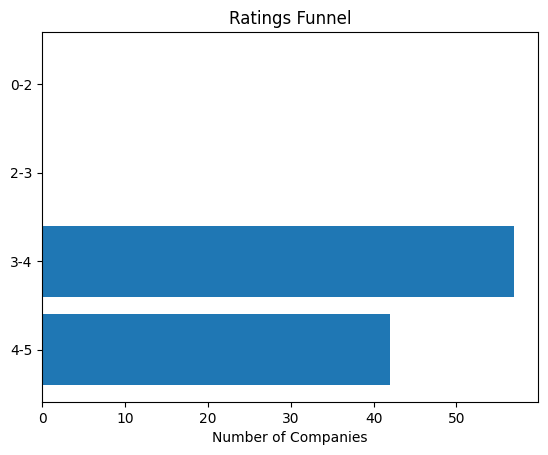

In [36]:
# Funnel chart - Rating wise
bins = [0, 2, 3, 4, 5]
labels = ['0-2', '2-3', '3-4', '4-5']
df['rating_bucket'] = pd.cut(df['ratings'], bins=bins, labels=labels)
funnel_data = df['rating_bucket'].value_counts().sort_index()

plt.barh(funnel_data.index, funnel_data.values)
plt.gca().invert_yaxis()
plt.title("Ratings Funnel")
plt.xlabel("Number of Companies")


Text(0, 0.5, 'Years')

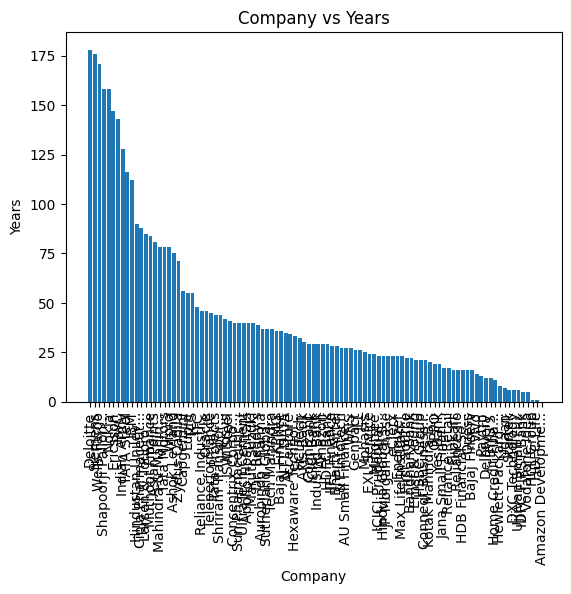

In [37]:
# Bar Chart
df['years_num'] = df['years'].str.extract(r'(\d+)').astype(float)
df_sorted = df.sort_values(by='years_num', ascending=False)
plt.bar(df_sorted['name'], df_sorted['years_num'])
plt.xticks(rotation=90)
plt.title("Company vs Years")
plt.xlabel("Company")
plt.ylabel("Years")


CType Mapping:
{0: 'Chennai + 64 more', 1: 'Hyderabad/Secunderabad + 45 more', 2: 'JV', 3: 'Partnership', 4: 'Private', 5: 'Public'}


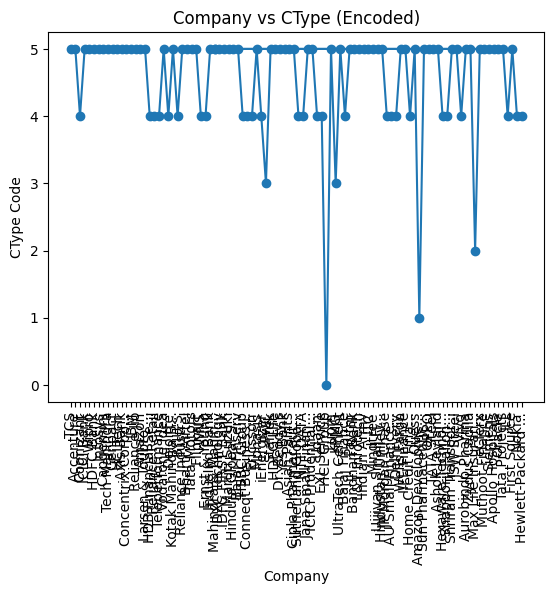

In [39]:
#Line Chart
df['ctype_encoded'] = df['ctype'].astype('category').cat.codes
plt.plot(df['name'], df['ctype_encoded'], marker='o')
plt.xticks(rotation=90)
plt.title("Company vs CType (Encoded)")
plt.xlabel("Company")
plt.ylabel("CType Code")

print("CType Mapping:")
print(dict(enumerate(df['ctype'].astype('category').cat.categories)))

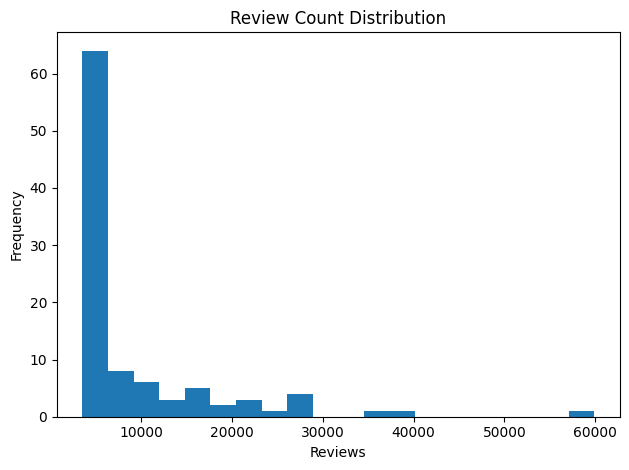

In [40]:
def parse_reviews(x):
    if pd.isna(x):
        return np.nan
    x = x.lower()
    x = x.replace('reviews', '').replace('(', '').replace(')', '').strip()

    if 'k' in x:
        return float(x.replace('k','')) * 1_000
    elif 'l' in x:
        return float(x.replace('l','')) * 100_000
    else:
        return float(x)

df['review_count_num'] = df['review_count'].apply(parse_reviews)

plt.hist(df['review_count_num'].dropna(), bins=20)
plt.title("Review Count Distribution")
plt.xlabel("Reviews")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()